# Zika - Import

## Setup

In [1]:
%reload_ext autoreload
%autoreload 2
from my_lib import *

## Dataset

In [2]:
df_zika = pd.read_csv("orig/train.csv")
display(Markdown("## `df_zika`"))
display(df_zika.shape)
display(df_zika.head(1))

## `df_zika`

(2138, 19)

,location,EW,EW_start_date,pop,cases,cases_est,cases_est_min,cases_est_max,p_rt1,p_inc100k,Sublocation,alert,id,model_version,tweet,Rt,receptivity,transmission,epidemic_threshold
0,A,201501,2015-01-04,12325232,0,0.0,0,0,0.5,0.0,0,1,355030820150119589,2023-08-20,0,0.0,0,0,0


In [3]:
df_score = pd.read_csv("orig/test.csv")
display(Markdown("## `df_score`"))
display(df_score.shape)
display(df_score.head(1))

## `df_score`

(572, 4)

,location,EW,EW_start_date,pop
0,A,202201,2022-01-02,12325232


In [4]:
df_dengue = pd.read_csv("orig/dengue.csv")
display(Markdown("## `df_dengue`"))
display(df_dengue.shape)
display(df_dengue.head(1))

## `df_dengue`

(3444, 10)

,location,EW,EW_start_date,cases,p_rt1,p_inc100k,alert,Rt,transmission,epidemic_threshold
0,A,201501,2015-01-04,370,1.0,3.001972,2,3.434149,1,1


In [5]:
df_weather = pd.read_csv("orig/weather.csv")
display(Markdown("## `df_weather`"))
display(df_weather.shape)
display(df_weather.head(1))

## `df_weather`

(19018, 28)

,location,date,temperature_2m_min,temperature_2m_max,temperature_2m_mean,apparent_temperature_min,apparent_temperature_max,apparent_temperature_mean,wind_speed_10m_max,wind_gusts_10m_max,wind_direction_10m_dominant,precipitation_sum,precipitation_hours,rain_sum,showers_sum,precipitation_probability_min,precipitation_probability_max,precipitation_probability_mean,sunshine_duration,daylight_duration,shortwave_radiation_sum,cloud_cover_mean,dew_point_2m_min,dew_point_2m_max,dew_point_2m_mean,relative_humidity_2m_mean,soil_moisture_0_to_7cm_mean,et0_fao_evapotranspiration
0,A,2015-01-04,21.036999,25.387,22.459915,23.57125,29.486015,25.565351,14.587776,28.44,137.45909,20.9,12.0,20.9,0.0,NaN,NaN,NaN,28601.842,48720.734,16.83,95.375,20.137,21.237,20.557833,89.229454,0.482583,3.162444


In [6]:
df_sample_submission = pd.read_csv("orig/sample_submission.csv")
display(Markdown("## `df_sample_submission`"))
display(df_sample_submission.shape)
display(df_sample_submission.head(1))

## `df_sample_submission`

(572, 2)

,ID,cases
0,A202201,1


## EDA

### Cleaning

* Convert data columns to dt
* Drop 2015 infection data
* Missing Values
* Fix the wrong date 3+11 issue by moving 2018-04-04

In [7]:
df_zika.dtypes

location               object
EW                      int64
EW_start_date          object
pop                     int64
cases                   int64
cases_est             float64
cases_est_min           int64
cases_est_max           int64
p_rt1                 float64
p_inc100k             float64
Sublocation             int64
alert                   int64
id                      int64
model_version          object
tweet                   int64
Rt                    float64
receptivity             int64
transmission            int64
epidemic_threshold      int64
dtype: object

In [8]:
for df in [df_zika, df_score, df_dengue]:
    df['EW_start_date'] = pd.to_datetime(df['EW_start_date'])

df_weather['date'] = pd.to_datetime(df_weather['date'])

In [9]:
df_zika.location.value_counts()

location
A    365
C    365
D    365
E    365
F    365
B    313
Name: count, dtype: int64

In [10]:
df_zika.groupby("EW_start_date").location.count().value_counts()

location
6    313
5     52
Name: count, dtype: int64

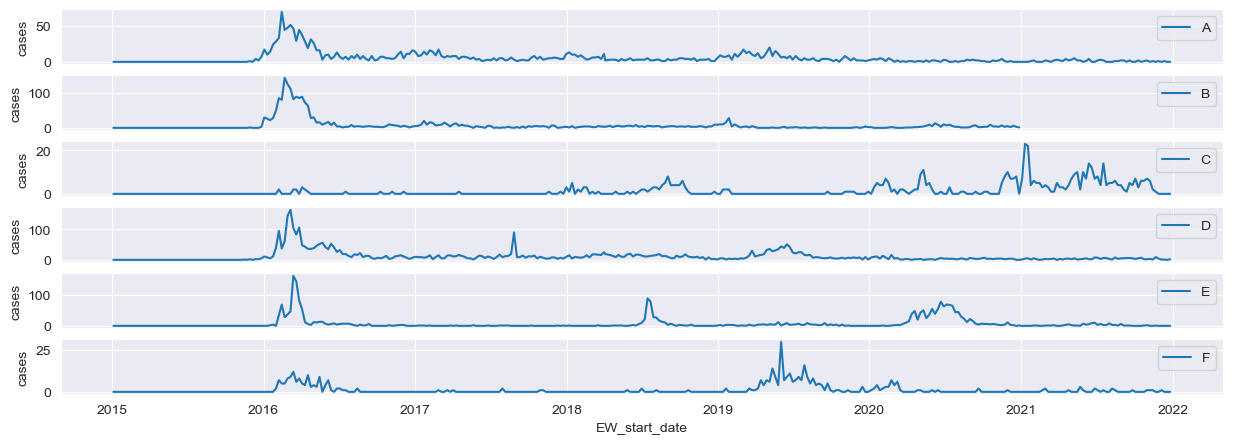

In [11]:
locations = df_zika.location.unique()
fig, axs = plt.subplots(len(locations), 1, figsize=(15, 5), sharex=True)

for location, ax in zip(locations, axs):
    criteria = "location == @location"
    sns.lineplot(data=df_zika.query(criteria), x="EW_start_date", y="cases", ax=ax, label=location)

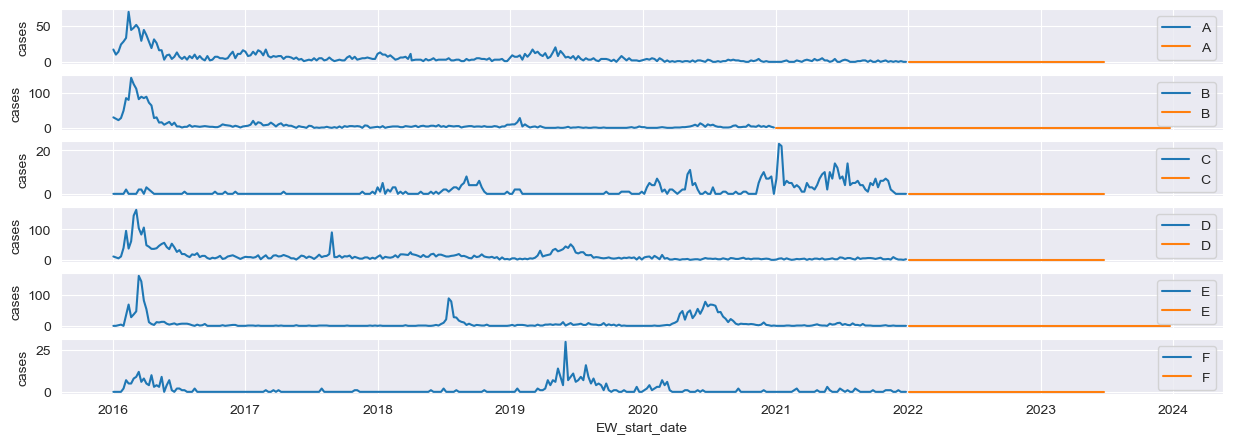

In [12]:
locations = df_zika.location.unique()
fig, axs = plt.subplots(len(locations), 1, figsize=(15, 5), sharex=True)

df_tmp = df_score.copy()
df_tmp['cases'] = 0

for location, ax in zip(locations, axs):
    criteria = "location == @location and EW_start_date >= '2016-01-01'"
    sns.lineplot(data=df_zika.query(criteria), x="EW_start_date", y="cases", ax=ax, label=location)
    # sns.lineplot(data=df_dengue.query(criteria), x="EW_start_date", y="cases", ax=ax, label=location)
    sns.lineplot(data=df_tmp.query(criteria), x="EW_start_date", y="cases", ax=ax, label=location)

In [13]:
df_zika.cases.mean()

np.float64(5.3952291861552855)

In [14]:
df_tmp = df_weather.isna().sum()
columns_to_drop = df_tmp[df_tmp > 0].index.tolist()
print(f"Columns to drop: {columns_to_drop}")
df_weather = df_weather.drop(columns=columns_to_drop)

Columns to drop: ['precipitation_probability_min', 'precipitation_probability_max', 'precipitation_probability_mean']


In [15]:
location = "A"
criteria = "location == @location"
df_z = df_zika.query(criteria)
df_d = df_dengue.query(criteria)
df_s = df_score.query(criteria)
df_w = df_weather.query(criteria)

In [16]:
df_tmp = (df_z.EW_start_date - df_z.EW_start_date.shift(1))
df_tmp.value_counts()

EW_start_date
7 days     362
3 days       1
11 days      1
Name: count, dtype: int64

In [17]:
irregular_date_index = df_tmp.index[df_tmp != '7 days'].tolist()
print(f"Irregular dates located at: {irregular_date_index}")

Irregular dates located at: [0, 170, 171]


In [18]:
df_tmp = df_z.copy()
display((df_tmp.iloc[[169, 170, 171]])['EW_start_date'])

169   2018-04-01
170   2018-04-04
171   2018-04-15
Name: EW_start_date, dtype: datetime64[ns]

In [19]:
df_tmp.at[170, 'EW_start_date'] = datetime.datetime(2018, 4, 8)
df_z = df_tmp.copy()
df_tmp = (df_z.EW_start_date - df_z.EW_start_date.shift(1))
irregular_date_index = df_tmp.index[df_tmp != '7 days'].tolist()
print(f"Irregular dates located at: {irregular_date_index}")

Irregular dates located at: [0]


In [20]:
df_i = pd.concat([df_z, df_s], ignore_index=True)
df_i[['EW_start_date']].head()

df_w[['date']].head()

df_w = pd.merge_asof(df_w, df_i[['EW_start_date']],
              left_on='date', right_on='EW_start_date', direction='backward')

In [21]:
cols = df_w.columns.to_list()
cols = cols[:2] + cols[-1:] + cols[2:-1]

df_w = df_w[cols].copy()

In [22]:
df_w.head(1)

,location,date,EW_start_date,temperature_2m_min,temperature_2m_max,temperature_2m_mean,apparent_temperature_min,apparent_temperature_max,apparent_temperature_mean,wind_speed_10m_max,wind_gusts_10m_max,wind_direction_10m_dominant,precipitation_sum,precipitation_hours,rain_sum,showers_sum,sunshine_duration,daylight_duration,shortwave_radiation_sum,cloud_cover_mean,dew_point_2m_min,dew_point_2m_max,dew_point_2m_mean,relative_humidity_2m_mean,soil_moisture_0_to_7cm_mean,et0_fao_evapotranspiration
0,A,2015-01-04,2015-01-04,21.036999,25.387,22.459915,23.57125,29.486015,25.565351,14.587776,28.44,137.45909,20.9,12.0,20.9,0.0,28601.842,48720.734,16.83,95.375,20.137,21.237,20.557833,89.229454,0.482583,3.162444


In [ ]:
weather_agg = {
    'temperature_2m_mean': ['mean', 'std'],
    'apparent_temperature_mean': ['mean', 'std'],
    'wind_speed_10m_max': ['mean', 'std'],
    'wind_gusts_10m_max': ['mean', 'std'],
    'wind_direction_10m_dominant': ['mean', 'std'],
    'precipitation_sum': ['mean', 'std'],
    'precipitation_hours': ['mean', 'std'],
    'rain_sum': ['mean', 'std'],
    'showers_sum': ['mean', 'std'],
    'sunshine_duration': ['mean', 'std'],
    'daylight_duration': ['mean', 'std'],
    'shortwave_radiation_sum': ['mean', 'std'],
    'cloud_cover_mean': ['mean', 'std'],
    'dew_point_2m_mean': ['mean', 'std'],
    'relative_humidity_2m_mean': ['mean', 'std'],
    'soil_moisture_0_to_7cm_mean': ['mean', 'std'],
    'et0_fao_evapotranspiration': ['mean', 'std']
}


In [24]:
df_tmp = df_w.groupby("EW_start_date").agg(weather_agg).reset_index()
df_tmp.head(1)

EW_start_date temperature_2m_mean         apparent_temperature_mean  \
                               mean     std                      mean   
0    2015-01-04            23.97688  1.6189                 27.194156   

             
        std  
0  1.972574

In [25]:
cols = [(f"{f}__{a}" if a else f"{f}") for f,a in df_tmp.columns]
df_tmp.columns = cols

In [26]:
for location in locations:
    import_data(location, weather_agg, df_zika, df_dengue, df_score, df_weather, debug=True)

Data imported for location A
Data imported for location B
Data imported for location C
Data imported for location D
Data imported for location E
Data imported for location F
